In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure, PerfMeasure, RatioMeasure
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
from walkforward_parameter_search import compute_grid_size
from synthetic_returns import estimate_marginal_stats, synthesize_returns
set_config(transform_output="pandas")
init_logger("CSCV_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\CSCV_252.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
log_print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2141 只 | 2604 天 | 2016-01-04 ~ 2026-09-18
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2603 天 x 2137 资产 | 列集一致: True


```python
    print(out["report"])                    # 四种分析报告（文本）
    out["pbo"]; out["loss_prob"]; out["degradation"]["slope"]
    out["dominance"]["fsd_holds"]; out["matrix"]; out["meta"]
    plot_cscv(out)                          # 四种分析图（各一张独立画布）
    print(build_topk_report(out, k=5))      # topK 冠军候选验收（文本,零重算）
    plot_topk(out, k=5)                     # topK 评估区累计净值（黑虚线=全员截面中位）
    out_mdd = cscv_pbo(X, space=search_space, block_size=252, S=16,
                       measure="MAX_DRAWDOWN")  # 切换评价度量（skfolio 口径）
```

In [3]:
from cscv_pbo_v3 import build_topk_report, cscv_pbo, plot_cscv, plot_topk

In [ ]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 55, 'step': 10},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.9, 'step': 0.4},
 'extremes__k': {'low': 0.1, 'high': 0.9, 'step': 0.4},
 'nondomin__fitness_measures': [
    #"mean-variance-kurt",
    #"mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    #"mean-semideviation-avgdd",
    #"mean-mad-maxdd-kurt",
    #"mean-mad-avgdd-kurt",
    #"mean-mad-maxdd-cvar-kurt",
    #"mean-mad-maxdd-cvar-sharpe",
    #"mean-mad-avgdd-cvar-kurt",
    #"mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 252}}  # inner train size
log_print(search_space, section='Search Space', echo=False)
compute_grid_size(search_space)

486

In [6]:
out = cscv_pbo(X, space=search_space, block_size=252, S=16)

空间枚举（v3）：6 维 -> N = 486 个配置（确定性网格，无搜索层）
  收益流构建（v3）：486 参数 x 7 块 x 252 天 = 1764 天 | 公共起点第 756 天（冗余 756 天）
  对齐网格：train_size 分 3 组，walkforward 每组定义一次、组内复用 | 折级并行 n_jobs = 7（上限即折数 7；省内存可显式传小）


收益流构建:   0%|          | 0/486 [00:00<?, ?候选/s]

In [ ]:
#import pickle, json
#pickle.dump(out, open("cscv_out_seed24_5000.pkl", "wb"))                      # 首选:整份留档
#json.dump(out["candidates"], open("candidates_seed24_500.json", "w"), default=str)  # 兜底:至少留候选参数

In [7]:
log_print( out["report"], section="CSCV PBO 诊断", echo=True)

   CSCV PBO 诊断 v3（空间枚举 N 次执行 + 四种分析，论文 3.1-3.3）
  候选集：参数空间网格 N = 486（6 维，无搜索层）
    - nondomin__min_n_assets: 5~55 step 10
    - nondomin__threshold: -0.5~-0.3 step 0.1
    - correlate__threshold: 0.1~0.9 step 0.4
    - extremes__k: 0.1~0.9 step 0.4
    - nondomin__fitness_measures: choice x1
    - train_size: 252~756 step 252
  收益流：486 参数 x 7 块 x 252 天 = 1764 天 | 公共起点第 756 天（冗余 max(train_size) = 756 天）
  评估区：2019-02-14 00:00:00+08:00 ~ 2026-05-25 00:00:00+08:00
  CSCV：S=16 块（每块 110 天）| 组合数 C(16,8) = 12870
  ---------- 四种分析 ----------
  [1] PBO = freq(lambda<=0) = 11.9%（1530/12870）| lambda 5/50/95 分位 = -0.94/+3.56/+5.78 | 冠军多样性 38/486
  [2] 性能退化：SR_OOS = +0.134 -0.593 x SR_IS（Spearman -0.425）| 可达 OOS 区间 P10/50/90 = +0.04/+0.08/+0.11
  [3] 亏损概率：Prob[SR_OOS(IS 冠军) < 0] = 0.7%
  [4] 随机占优：FSD = 否（CDF 最大反超 +0.0000）| SD2 min = +0.0000 -> 仅二阶占优（风险厌恶下优于随机选择）
  解读：PBO 越接近 0 排名传递性越好（论文惯例阈值 5%）；≈50% 表示选择与随机无异；
        亏损概率与 PBO 独立——PBO 低而亏损概率高说明 OOS 乏力且非过拟合所致；
        斜率显著为负 + FSD/SD2 均不成立 = 过拟合的典

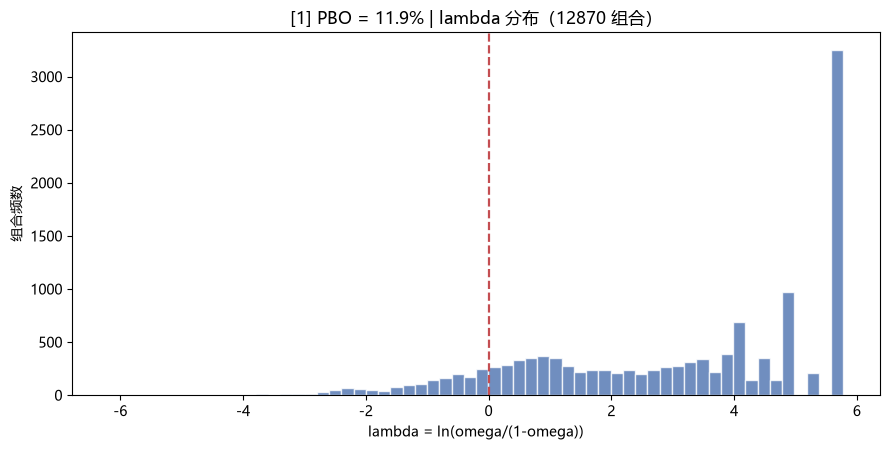

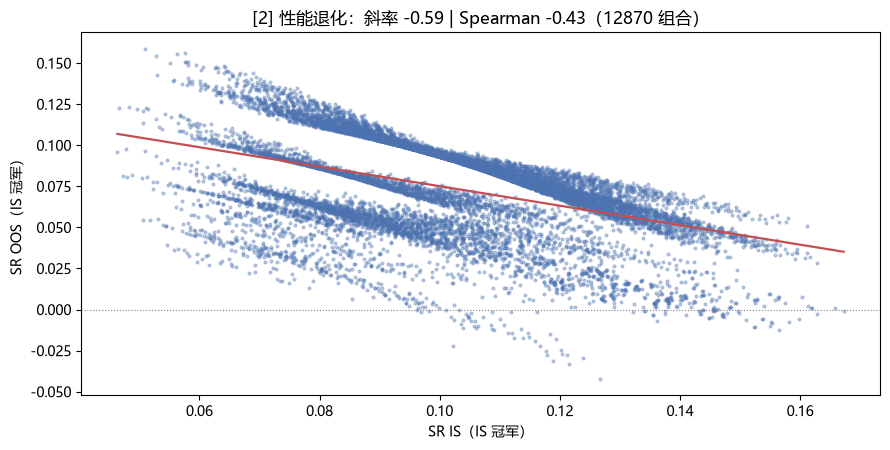

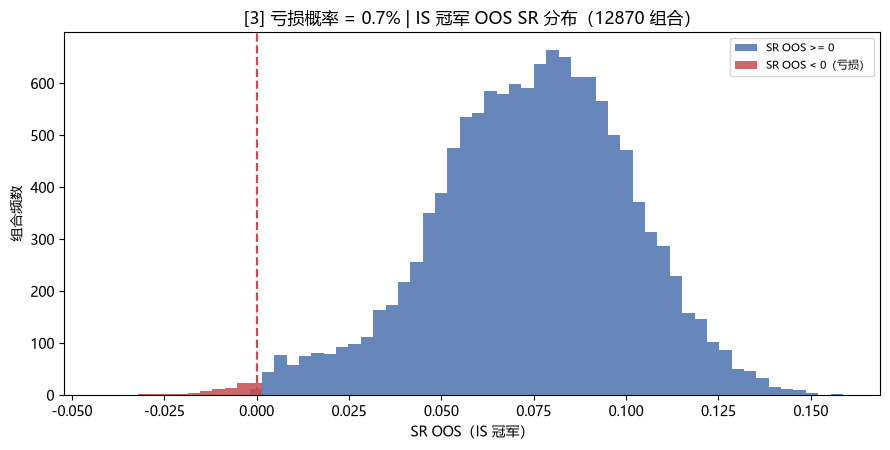

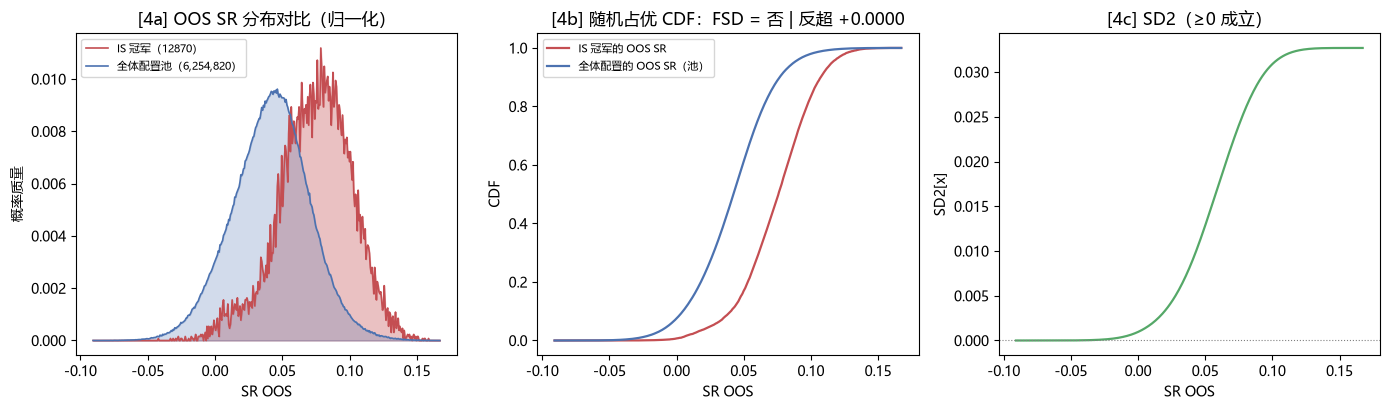

{'pbo': <Figure size 900x460 with 1 Axes>,
 'degradation': <Figure size 900x460 with 1 Axes>,
 'loss': <Figure size 900x460 with 1 Axes>,
 'dominance': <Figure size 1400x420 with 3 Axes>}

In [8]:
plot_cscv(out)                                          # lambda 分布图

In [11]:
print(build_topk_report(out, k=5))      # topK 冠军候选验收（文本,零重算）

[数据来源] 零重算 | 候选 N=486 x 评估区 T=1764 天 | 对称组合 12870 个 | S=16
[top5 定位(夺冠次数 | 参数)]
  7556  {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 504}
  1498  {'nondomin__min_n_assets': 45, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 504}
  754  {'nondomin__min_n_assets': 55, 'nondomin__threshold': -0.4, 'correlate__threshold': 0.1, 'extremes__k': 0.5, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 252}
  550  {'nondomin__min_n_assets': 45, 'nondomin__threshold': -0.5, 'correlate__threshold': 0.5, 'extremes__k': 0.9, 'nondomin__fitness_measures': 'mean-variance-avgdd-kurt', 'train_size': 756}
  490  {'nondomin__min_n_assets': 5, 'nondomin__threshold': -0.3, 'correlate__threshold': 0.1, 'extremes__k': 0.9, 'nondomin__fitness_measures': '

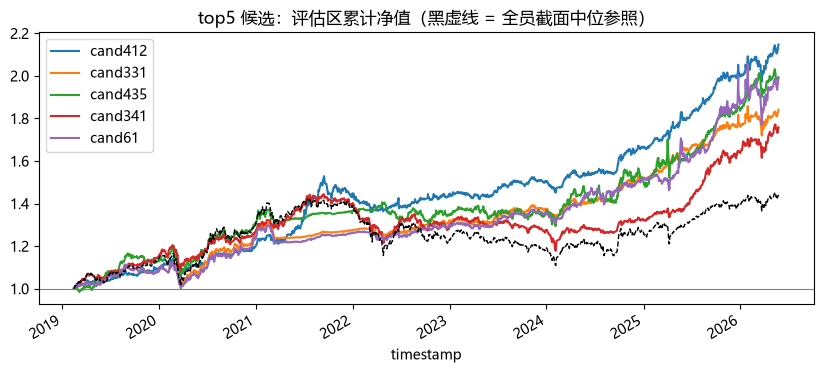

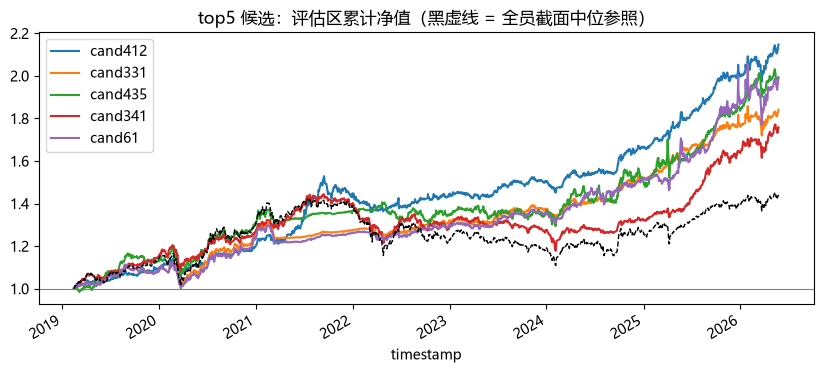

In [12]:
plot_topk(out, k=5)                     # topK 评估区累计净值（黑虚线=全员截面中位）